# Etapa 3 — Camada Silver (Pessoa 3)

Objetivo: limpar e preparar os dados para Machine Learning com justificativas técnicas.

Checklist desta etapa:
- tratar nulos
- remover duplicados
- padronizar categorias
- converter/tratar datas
- criar label final
- remover colunas com risco de data leakage
- documentar decisões
- salvar dataset Silver em Parquet

## 1) Configuração de caminhos

In [17]:
from pathlib import Path
from datetime import datetime
import json

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data"
BRONZE_PATH = DATA_PATH / "bronze"
SILVER_PATH = DATA_PATH / "silver"
DOCS_PATH = PROJECT_ROOT / "docs"

RUN_DATE = datetime.now().strftime("%Y-%m-%d")
SILVER_RUN_PATH = SILVER_PATH / RUN_DATE

for p in (SILVER_PATH, SILVER_RUN_PATH, DOCS_PATH):
    p.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"BRONZE_PATH: {BRONZE_PATH}")
print(f"SILVER_PATH: {SILVER_PATH}")
print(f"SILVER_RUN_PATH: {SILVER_RUN_PATH}")
print(f"DOCS_PATH: {DOCS_PATH}")

PROJECT_ROOT: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project
BRONZE_PATH: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\data\bronze
SILVER_PATH: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\data\silver
SILVER_RUN_PATH: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\data\silver\2026-04-05
DOCS_PATH: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\docs


In [2]:
import os
import pandas as pd
from pathlib import Path
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Configuração do Java (necessária para PySpark)
if not os.environ.get("JAVA_HOME"):
    possible_jdks = [
        Path(r"C:\Program Files\Java\jdk-23"),
        Path(r"C:\Program Files\Eclipse Adoptium\jdk-17"),
        Path(r"C:\Program Files\Microsoft\jdk-17"),
    ]
    for jdk in possible_jdks:
        if (jdk / "bin" / "java.exe").exists():
            os.environ["JAVA_HOME"] = str(jdk)
            break

if os.environ.get("JAVA_HOME"):
    os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ.get("PATH", "")
else:
    raise EnvironmentError("JAVA_HOME não encontrado. Configure o JDK antes de iniciar o PySpark.")

# Compatibilidade para Java moderno
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--conf spark.driver.extraJavaOptions=-Djava.security.manager=allow "
    "--conf spark.executor.extraJavaOptions=-Djava.security.manager=allow pyspark-shell"
)

try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("cybersecurity_silver_step3")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.hadoop.hadoop.security.authentication", "simple")
    .config("spark.hadoop.hadoop.security.authorization", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("Spark iniciado:", spark.version)
print("Obs: se houver erro getSubject na leitura/escrita Parquet com Java 23, será usado fallback com pandas apenas para I/O.")

JAVA_HOME: C:\Program Files\Java\jdk-23
Spark iniciado: 4.1.1
Obs: se houver erro getSubject na leitura/escrita Parquet com Java 23, será usado fallback com pandas apenas para I/O.


## 2) Leitura da Bronze (PySpark)

In [3]:
bronze_candidates = list(BRONZE_PATH.glob("*.parquet"))

if not bronze_candidates:
    dated_dirs = sorted([p for p in BRONZE_PATH.iterdir() if p.is_dir()]) if BRONZE_PATH.exists() else []
    if dated_dirs:
        latest = dated_dirs[-1]
        bronze_candidates = list(latest.glob("*.parquet"))
        print(f"Usando fallback da pasta datada: {latest}")

incident_file = None
for p in bronze_candidates:
    if "incidents_master" in p.stem and "validated" not in p.stem:
        incident_file = p
        break

if incident_file is None:
    raise FileNotFoundError("Arquivo incidents_master.parquet não encontrado em data/bronze")

try:
    df_incidents = spark.read.parquet(str(incident_file))
    print("Leitura Parquet via Spark: OK")
except Exception as e:
    if "getSubject is supported only if a security manager is allowed" in str(e):
        print("Leitura Spark falhou por incompatibilidade Java/Hadoop. Usando fallback pandas -> lista de dict -> Spark.")
        pdf_incidents = pd.read_parquet(incident_file)
        rows = pdf_incidents.to_dict(orient="records")
        df_incidents = spark.createDataFrame(rows)
    else:
        raise

print(f"Arquivo carregado: {incident_file.name}")
print(f"Registros Bronze: {df_incidents.count()} | Colunas: {len(df_incidents.columns)}")

Usando fallback da pasta datada: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\data\bronze\2026-04-05
Leitura Parquet via Spark: OK
Arquivo carregado: incidents_master.parquet
Registros Bronze: 850 | Colunas: 34


## 3) Diagnóstico Bronze

In [4]:
total_registros = df_incidents.count()

dup_exact = total_registros - df_incidents.dropDuplicates().count()
dup_incident_id = 0
if "incident_id" in df_incidents.columns:
    dup_incident_id = total_registros - df_incidents.select("incident_id").dropDuplicates().count()

print("=" * 80)
print("DIAGNÓSTICO BRONZE")
print("=" * 80)
print(f"Total registros: {total_registros}")
print(f"Duplicatas exatas: {dup_exact}")
print(f"Duplicatas por incident_id: {dup_incident_id}")

DIAGNÓSTICO BRONZE
Total registros: 850
Duplicatas exatas: 0
Duplicatas por incident_id: 0


In [5]:
null_counts = df_incidents.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_incidents.columns]).collect()[0]

print("\nTop colunas com nulos (Bronze):")
null_summary = []
for c in df_incidents.columns:
    cnt = null_counts[c]
    pct = (cnt / total_registros * 100) if total_registros else 0
    if cnt > 0:
        null_summary.append((c, cnt, pct))

for c, cnt, pct in sorted(null_summary, key=lambda x: x[2], reverse=True)[:15]:
    print(f"{c:.<40} {cnt:>5} ({pct:>6.2f}%)")


Top colunas com nulos (Bronze):
review_flag.............................   780 ( 91.76%)
industry_secondary......................   697 ( 82.00%)
attack_vector_secondary.................   639 ( 75.18%)
notes...................................   636 ( 74.82%)
data_source_secondary...................   464 ( 54.59%)
stock_ticker............................   438 ( 51.53%)
downtime_hours..........................   430 ( 50.59%)
attributed_group........................   368 ( 43.29%)
attribution_confidence..................   368 ( 43.29%)
attack_chain............................   275 ( 32.35%)
data_compromised_records................   248 ( 29.18%)
data_type...............................   248 ( 29.18%)


In [6]:
df_incidents.printSchema()

root
 |-- incident_id: string (nullable = true)
 |-- company_name: string (nullable = true)
 |-- company_revenue_usd: double (nullable = true)
 |-- country_hq: string (nullable = true)
 |-- industry_primary: string (nullable = true)
 |-- industry_secondary: string (nullable = true)
 |-- employee_count: long (nullable = true)
 |-- is_public_company: boolean (nullable = true)
 |-- stock_ticker: string (nullable = true)
 |-- incident_date: string (nullable = true)
 |-- incident_date_estimated: boolean (nullable = true)
 |-- discovery_date: string (nullable = true)
 |-- disclosure_date: string (nullable = true)
 |-- attack_vector_primary: string (nullable = true)
 |-- attack_vector_secondary: string (nullable = true)
 |-- attack_chain: string (nullable = true)
 |-- attributed_group: string (nullable = true)
 |-- attribution_confidence: string (nullable = true)
 |-- data_compromised_records: double (nullable = true)
 |-- data_type: string (nullable = true)
 |-- systems_affected: string (nul

## 4) Transformações Silver (limpeza, padronização, datas, label, anti-leakage)

In [7]:
df_silver = df_incidents.dropDuplicates()
if "incident_id" in df_silver.columns:
    df_silver = df_silver.dropDuplicates(["incident_id"])

print(f"Registros após deduplicação: {df_silver.count()}")

Registros após deduplicação: 850


In [8]:
string_cols = [f.name for f in df_silver.schema.fields if f.dataType.simpleString() == "string"]

for c in string_cols:
    df_silver = df_silver.withColumn(c, F.when(F.trim(F.col(c)) == "", None).otherwise(F.col(c)))

categorical_cols = [
    c for c in [
        "country_hq", "industry_primary", "industry_secondary",
        "attack_vector_primary", "attack_vector_secondary",
        "attack_chain", "attributed_group", "attribution_confidence",
        "data_source_type", "quality_grade", "review_flag"
    ] if c in df_silver.columns
]
for c in categorical_cols:
    df_silver = df_silver.withColumn(c, F.lower(F.trim(F.col(c))))

if "review_flag" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "review_flag",
        F.when(F.col("review_flag").isin("1", "true", "yes", "y", "sim"), F.lit("true"))
         .when(F.col("review_flag").isin("0", "false", "no", "n", "nao"), F.lit("false"))
         .otherwise(F.col("review_flag"))
    )

if "data_compromised_records" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "data_compromised_records",
        F.when(F.col("data_compromised_records") < 0, None).otherwise(F.col("data_compromised_records"))
    )
if "downtime_hours" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "downtime_hours",
        F.when(F.col("downtime_hours") < 0, None).otherwise(F.col("downtime_hours"))
    )

print("Nulos/categorias padronizados.")

Nulos/categorias padronizados.


In [9]:
# 4.2 Datas + features + label + anti-leakage
date_cols = [c for c in ["incident_date", "discovery_date", "disclosure_date", "created_at", "updated_at"] if c in df_silver.columns]
for c in date_cols:
    df_silver = df_silver.withColumn(c, F.to_timestamp(F.col(c)))

# coerência temporal (mantém apenas linhas válidas)
if all(c in df_silver.columns for c in ["incident_date", "discovery_date", "disclosure_date"]):
    df_silver = df_silver.filter(
        (F.col("incident_date").isNull() | F.col("discovery_date").isNull() | (F.col("incident_date") <= F.col("discovery_date")))
        &
        (F.col("discovery_date").isNull() | F.col("disclosure_date").isNull() | (F.col("discovery_date") <= F.col("disclosure_date")))
    )

# features derivadas
if "incident_date" in df_silver.columns:
    df_silver = (df_silver
        .withColumn("incident_year", F.year(F.col("incident_date")))
        .withColumn("incident_month", F.month(F.col("incident_date")))
        .withColumn("incident_day", F.dayofmonth(F.col("incident_date")))
    )

if all(c in df_silver.columns for c in ["discovery_date", "incident_date"]):
    df_silver = df_silver.withColumn("days_to_discovery", F.datediff(F.col("discovery_date"), F.col("incident_date")))
if all(c in df_silver.columns for c in ["disclosure_date", "incident_date"]):
    df_silver = df_silver.withColumn("days_to_disclosure", F.datediff(F.col("disclosure_date"), F.col("incident_date")))

if "data_compromised_records" in df_silver.columns:
    df_silver = df_silver.withColumn("has_data_loss", F.when(F.col("data_compromised_records") > 0, 1).otherwise(0))
if "downtime_hours" in df_silver.columns:
    df_silver = df_silver.withColumn("has_downtime", F.when(F.col("downtime_hours") > 0, 1).otherwise(0))

# Label final para ML: incidente severo quando houve perda de dados OU downtime
if all(c in df_silver.columns for c in ["has_data_loss", "has_downtime"]):
    df_silver = df_silver.withColumn("label_severe_incident", F.when((F.col("has_data_loss") == 1) | (F.col("has_downtime") == 1), 1).otherwise(0))

# Remoção de colunas com risco de leakage
leakage_cols = [
    c for c in [
        "quality_score", "quality_grade", "review_flag",
        "notes", "disclosure_date", "updated_at",
        "ingestion_timestamp", "source_file", "quality_flag"
    ] if c in df_silver.columns
]
df_silver = df_silver.drop(*leakage_cols)

print("Transformações Silver aplicadas.")
print(f"Colunas removidas por leakage: {leakage_cols}")

Transformações Silver aplicadas.
Colunas removidas por leakage: ['quality_score', 'quality_grade', 'review_flag', 'notes', 'disclosure_date', 'updated_at', 'ingestion_timestamp', 'source_file']


In [10]:
# seleção final (somente colunas existentes)
priority_cols = [
    "incident_id", "incident_date", "discovery_date",
    "incident_year", "incident_month", "incident_day",
    "country_hq", "industry_primary", "attack_vector_primary",
    "data_compromised_records", "downtime_hours",
    "has_data_loss", "has_downtime",
    "days_to_discovery", "days_to_disclosure",
    "label_severe_incident"
]
final_cols = [c for c in priority_cols if c in df_silver.columns] + [c for c in df_silver.columns if c not in priority_cols]
df_silver = df_silver.select(*final_cols)

print(f"Registros Silver: {df_silver.count()}")
print(f"Colunas Silver: {len(df_silver.columns)}")
df_silver.printSchema()

Registros Silver: 850
Colunas Silver: 34
root
 |-- incident_id: string (nullable = true)
 |-- incident_date: timestamp (nullable = true)
 |-- discovery_date: timestamp (nullable = true)
 |-- incident_year: integer (nullable = true)
 |-- incident_month: integer (nullable = true)
 |-- incident_day: integer (nullable = true)
 |-- country_hq: string (nullable = true)
 |-- industry_primary: string (nullable = true)
 |-- attack_vector_primary: string (nullable = true)
 |-- data_compromised_records: double (nullable = true)
 |-- downtime_hours: double (nullable = true)
 |-- has_data_loss: integer (nullable = false)
 |-- has_downtime: integer (nullable = false)
 |-- days_to_discovery: integer (nullable = true)
 |-- days_to_disclosure: integer (nullable = true)
 |-- label_severe_incident: integer (nullable = false)
 |-- company_name: string (nullable = true)
 |-- company_revenue_usd: double (nullable = true)
 |-- industry_secondary: string (nullable = true)
 |-- employee_count: long (nullable =

## 5) Validação final e documentação de decisões

In [11]:
total_silver = df_silver.count()
dup_after = total_silver - df_silver.dropDuplicates().count()

print("=" * 80)
print("VALIDAÇÃO SILVER")
print("=" * 80)
print(f"Total registros: {total_silver}")
print(f"Duplicatas exatas após limpeza: {dup_after}")

null_after = df_silver.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_silver.columns]).collect()[0]
null_cols_after = [(c, null_after[c]) for c in df_silver.columns if null_after[c] > 0]
print(f"Colunas com nulos após tratamento: {len(null_cols_after)}")
print("Label distribution:")
if "label_severe_incident" in df_silver.columns:
    df_silver.groupBy("label_severe_incident").count().orderBy("label_severe_incident").show()

VALIDAÇÃO SILVER
Total registros: 850
Duplicatas exatas após limpeza: 0
Colunas com nulos após tratamento: 10
Label distribution:
+---------------------+-----+
|label_severe_incident|count|
+---------------------+-----+
|                    0|  118|
|                    1|  732|
+---------------------+-----+



In [12]:
decisions_md = f"""# Decisões — Etapa 3 (Camada Silver)

Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Transformações aplicadas
- Remoção de duplicatas exatas e por incident_id.
- Tratamento de nulos (strings vazias -> null; negativos inválidos -> null).
- Padronização de categorias com trim/lower.
- Conversão de datas para timestamp e validação de coerência temporal.
- Criação de features derivadas: incident_year/month/day, days_to_discovery, days_to_disclosure.
- Criação de label final `label_severe_incident`.

## Justificativas
- **Colunas removidas (leakage):** quality_score, quality_grade, review_flag, notes, disclosure_date, updated_at, ingestion_timestamp, source_file, quality_flag.
- **Por que remover:** contêm informação de avaliação posterior ao evento, anotação manual, metadados operacionais ou atributos que podem vazar o alvo.
- **Por que este label:** `label_severe_incident=1` quando houve perda de dados (`has_data_loss`) ou indisponibilidade (`has_downtime`), representando severidade operacional relevante para ML.
- **Por que tratar dados:** reduzir ruído, inconsistência e vieses de digitação/formatação para melhorar robustez do modelo.
"""

anti_leakage_md = """# Checklist Anti-Leakage — Silver

| Coluna | Risco | Decisão | Justificativa |
|---|---|---|---|
| quality_score | Alto | Remover | Score derivado de qualidade posterior ao evento |
| quality_grade | Alto | Remover | Classe de avaliação posterior ao evento |
| review_flag | Alto | Remover | Sinal de revisão humana posterior |
| notes | Médio/Alto | Remover | Texto livre pode conter informação de desfecho |
| disclosure_date | Alto | Remover | Pode ocorrer após o evento e revelar severidade |
| updated_at | Alto | Remover | Timestamp de atualização pós-evento |
| ingestion_timestamp | Médio | Remover | Metadado operacional sem valor preditivo |
| source_file | Médio | Remover | Metadado técnico que pode introduzir viés |
| quality_flag | Alto | Remover | Resultado de validação/curadoria pós-ingestão |
"""

(DOCS_PATH / "silver_decisions.md").write_text(decisions_md, encoding="utf-8")
(DOCS_PATH / "anti_leakage_checklist.md").write_text(anti_leakage_md, encoding="utf-8")
print("Documentos gerados:")
print(DOCS_PATH / "silver_decisions.md")
print(DOCS_PATH / "anti_leakage_checklist.md")

Documentos gerados:
C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\docs\silver_decisions.md
C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\docs\anti_leakage_checklist.md


In [13]:
pdf = df_silver.select(
    *[c for c in ["incident_year", "country_hq", "industry_primary", "label_severe_incident"] if c in df_silver.columns]
).toPandas()

if not pdf.empty:
    display(pdf.head())

    if "label_severe_incident" in pdf.columns:
        print("Distribuição do label:")
        print(pdf["label_severe_incident"].value_counts(dropna=False))

    if "incident_year" in pdf.columns:
        print("Incidentes por ano:")
        print(pdf.groupby("incident_year").size().sort_index().tail(10))

    if "country_hq" in pdf.columns:
        print("Top países:")
        print(pdf["country_hq"].value_counts(dropna=False).head(10))

,incident_year,country_hq,industry_primary,label_severe_incident
0,2021,br,21,1
1,2021,us,31-33,1
2,2021,us,31-33,1
3,2021,us,22,1
4,2021,jp,52,1


Distribuição do label:
label_severe_incident
1    732
0    118
Name: count, dtype: int64
Incidentes por ano:
incident_year
2021    131
2022    143
2023    166
2024    181
2025    229
dtype: int64
Top países:
country_hq
us    298
gb     90
de     50
ca     48
fr     40
au     37
jp     35
in     25
it     20
br     17
Name: count, dtype: int64


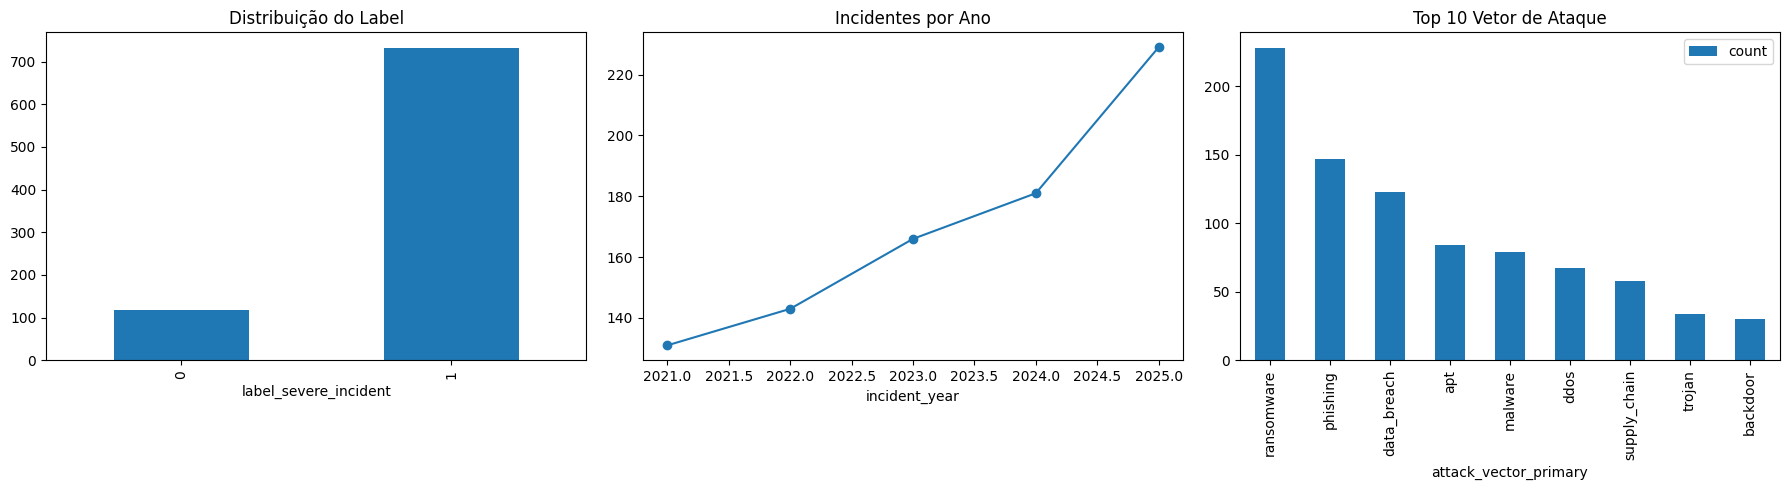

In [14]:
import matplotlib.pyplot as plt

if not pdf.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if "label_severe_incident" in pdf.columns:
        pdf["label_severe_incident"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Distribuição do Label")
    else:
        axes[0].set_title("Distribuição do Label (indisponível)")

    if "incident_year" in pdf.columns:
        pdf.groupby("incident_year").size().sort_index().plot(kind="line", marker="o", ax=axes[1], title="Incidentes por Ano")
    else:
        axes[1].set_title("Incidentes por Ano (indisponível)")

    if "attack_vector_primary" in df_silver.columns:
        df_silver.groupBy("attack_vector_primary").count().orderBy(F.desc("count")).limit(10).toPandas().plot(
            kind="bar", x="attack_vector_primary", y="count", ax=axes[2], title="Top 10 Vetor de Ataque"
        )
    else:
        axes[2].set_title("Top Vetor de Ataque (indisponível)")

    plt.tight_layout()
    plt.show()

## 6) Salvar Silver em Parquet

In [18]:
from py4j.protocol import Py4JJavaError
import shutil

silver_target_dir = SILVER_RUN_PATH / "incidents_master"
silver_target_file = SILVER_RUN_PATH / "incidents_master.parquet"

def _can_fallback_to_pandas(err: Exception) -> bool:
    msg = str(err)
    known_java_io_issues = [
        "getSubject is supported only if a security manager is allowed",
        "org.apache.hadoop.util.Shell.checkHadoopHome",
        "HADOOP_HOME",
        "winutils",
    ]
    return any(token.lower() in msg.lower() for token in known_java_io_issues)

# Primeiro tenta escrita nativa Spark; se falhar por incompatibilidade Java/Hadoop, usa fallback pandas
try:
    df_silver.coalesce(1).write.mode("overwrite").parquet(str(silver_target_dir))

    part_files = list(silver_target_dir.glob("*.parquet"))
    if not part_files:
        raise RuntimeError("Nenhum arquivo parquet gerado pela escrita Spark.")

    if silver_target_file.exists():
        silver_target_file.unlink()
    part_files[0].replace(silver_target_file)

    # limpeza da pasta temporária gerada pelo Spark
    shutil.rmtree(silver_target_dir, ignore_errors=True)
    print("Escrita Parquet via Spark: OK")

except Exception as e:
    if isinstance(e, Py4JJavaError) and _can_fallback_to_pandas(e):
        print("Escrita Spark falhou por incompatibilidade Java/Hadoop no Windows. Usando fallback pandas para salvar parquet.")
        if silver_target_dir.exists():
            shutil.rmtree(silver_target_dir, ignore_errors=True)
        df_silver.toPandas().to_parquet(silver_target_file, index=False)
    else:
        raise

print(f"Silver salvo em: {silver_target_file}")
print(f"Registros salvos: {df_silver.count()}")

Escrita Spark falhou por incompatibilidade Java/Hadoop no Windows. Usando fallback pandas para salvar parquet.
Silver salvo em: C:\Users\joaop\OneDrive\Área de Trabalho\JPSS\Isaac\Ciência de Dados\projeto 1\cybersecurity-breach-data-project\data\silver\2026-04-05\incidents_master.parquet
Registros salvos: 850
